# Social Media Emotion Analyzer - Model Development
This notebook shows the complete process for data loading, preprocessing, classical modeling, and transformer fine-tuning.

## 1. Data Loading and Exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/emotion_clean.csv')
display(df.head())

,text,emotion,clean_text
0,i didnt feel humiliated,sadness,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,sadness,can go feeling so hopeless so damned hopeful j...
2,im grabbing a minute to post i feel greedy wrong,anger,im grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,love,am ever feeling nostalgic about fireplace will...
4,i am feeling grouchy,anger,am feeling grouchy


In [2]:
# Check class distribution
emotion_counts = df['emotion'].value_counts()
print(emotion_counts)

emotion
joy         6761
sadness     5797
anger       2709
fear        2373
love        1641
surprise     719
Name: count, dtype: int64


## 2. Text Preprocessing
Here we implement text cleaning directly without relying on external files.

In [3]:
import re

STOPWORDS = {"a", "am", "an", "and", "are", "as", "at", "be", "but", "by", "for", "from", "has", "have", "he", "i", "in", "is", "it", "its", "me", "my", "of", "on", "or", "our", "she", "so", "that", "the", "their", "them", "they", "this", "to", "was", "we", "were", "with", "you", "your"}

def clean_text(text: str) -> str:
    text = "" if text is None else str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [t for t in text.split() if t not in STOPWORDS]
    return " ".join(tokens)

sample = 'I am feeling so happy today!!! @friend #Joy'
print("Original:", sample)
print("Cleaned:", clean_text(sample))

# Apply to dataset
df['clean_text_notebook'] = df['text'].apply(clean_text)

Original: I am feeling so happy today!!! @friend #Joy
Cleaned: feeling happy today joy


## 3. Feature Extraction and Classical Models
We split the data and train TF-IDF Bigram + SVM, Count Bigram + Logistic Regression, and Count Bigram + Random Forest.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text_notebook"],
    df["emotion"],
    test_size=0.2,
    random_state=42,
    stratify=df["emotion"]
)

### TF-IDF Bigram + SVM

In [5]:
pipeline_svm = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
    ("classifier", CalibratedClassifierCV(LinearSVC(class_weight="balanced"), cv=3))
])
pipeline_svm.fit(X_train, y_train)
y_pred_svm = pipeline_svm.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.905
              precision    recall  f1-score   support

       anger       0.91      0.87      0.89       542
        fear       0.89      0.87      0.88       475
         joy       0.92      0.93      0.93      1352
        love       0.81      0.84      0.83       328
     sadness       0.93      0.95      0.94      1159
    surprise       0.79      0.74      0.76       144

    accuracy                           0.91      4000
   macro avg       0.88      0.87      0.87      4000
weighted avg       0.90      0.91      0.90      4000



### Count Bigram + Logistic Regression

In [6]:
pipeline_lr = Pipeline([
    ("count", CountVectorizer(ngram_range=(1, 2), min_df=2)),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.89775
              precision    recall  f1-score   support

       anger       0.89      0.87      0.88       542
        fear       0.88      0.85      0.87       475
         joy       0.93      0.91      0.92      1352
        love       0.75      0.87      0.81       328
     sadness       0.95      0.92      0.93      1159
    surprise       0.72      0.83      0.77       144

    accuracy                           0.90      4000
   macro avg       0.85      0.88      0.86      4000
weighted avg       0.90      0.90      0.90      4000



### Count Bigram + Random Forest

In [7]:
pipeline_rf = Pipeline([
    ("count", CountVectorizer(ngram_range=(1, 2), min_df=2)),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced", n_jobs=-1))
])
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.89325
              precision    recall  f1-score   support

       anger       0.90      0.85      0.87       542
        fear       0.85      0.87      0.86       475
         joy       0.92      0.92      0.92      1352
        love       0.78      0.89      0.83       328
     sadness       0.95      0.90      0.92      1159
    surprise       0.75      0.82      0.78       144

    accuracy                           0.89      4000
   macro avg       0.85      0.87      0.86      4000
weighted avg       0.90      0.89      0.89      4000



## 4. DistilBERT Bonus Model
We use huggingface transformers to fine-tune DistilBERT.

In [8]:
# Note: This requires 'transformers' and 'datasets' libraries.
import os
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding

label_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]
label_to_id = {label: idx for idx, label in enumerate(label_names)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

# Sample a smaller subset for demonstration in notebook
df_sample = df.sample(n=1000, random_state=42).copy()
df_sample["label"] = df_sample["emotion"].map(label_to_id)

train_df, eval_df = train_test_split(df_sample[["text", "label"]], test_size=0.2, random_state=42, stratify=df_sample["label"])
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
eval_dataset = Dataset.from_pandas(eval_df.reset_index(drop=True))

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
def tokenize(batch):
    return tokenizer(batch["text"], truncation=True)

train_dataset = train_dataset.map(tokenize, batched=True)
eval_dataset = eval_dataset.map(tokenize, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_names),
    id2label=id_to_label,
    label2id=label_to_id,
)

training_args = TrainingArguments(
    output_dir="./distilbert_demo",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    eval_strategy="epoch",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
)

trainer.train() # Uncomment to run the training locally in the notebook

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_2275/171091534.py:46: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,No log,1.357343


TrainOutput(global_step=100, training_loss=1.5151069641113282, metrics={'train_runtime': 11.827, 'train_samples_per_second': 67.642, 'train_steps_per_second': 8.455, 'total_flos': 8666883798624.0, 'train_loss': 1.5151069641113282, 'epoch': 1.0})

## 5. Model Comparison Table
Which model performs best? We compare all three models on Accuracy, Precision, Recall, and F1-score.
The **best value** in each metric column is highlighted in green.

In [9]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from IPython.display import HTML
import pandas as pd
import pathlib

LABEL_NAMES = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

# Classical models: compute metrics from live predictions
classical = [
    ('TF-IDF Bigram + SVM',          y_pred_svm),
    ('Count Bigram + Logistic Reg.', y_pred_lr),
    ('Count Bigram + Random Forest', y_pred_rf),
]
rows = []
for name, y_pred in classical:
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0)
    rows.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                 'Recall': rec, 'F1-Score': f1})

# DistilBERT: load saved metrics from model_results.csv
results_csv = pathlib.Path('..') / 'models' / 'classical' / 'model_results.csv'
if results_csv.exists():
    results_df = pd.read_csv(results_csv)
    bert_row   = results_df[results_df['display_name'] == 'DistilBERT']
    if not bert_row.empty:
        b = bert_row.iloc[0]
        rows.append({'Model': '\U0001f916 DistilBERT (Transformer)',
                     'Accuracy': b['accuracy'], 'Precision': b['precision'],
                     'Recall':   b['recall'],   'F1-Score': b['f1']})
    else:
        print('\u26a0\ufe0f  DistilBERT not found in model_results.csv')
else:
    print('\u26a0\ufe0f  model_results.csv not found')

comparison_df = (
    pd.DataFrame(rows)
    .sort_values('F1-Score', ascending=False)
    .reset_index(drop=True)
)

medal_map   = {0: '\U0001f947 #1', 1: '\U0001f948 #2', 2: '\U0001f949 #3',
               3: '\U0001f3c5 #4'}
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
best_vals   = {col: comparison_df[col].max() for col in metric_cols}

TH = ('background-color:#1a1a2e; color:#ffffff; font-size:13px; '
      'text-align:center; padding:10px 16px; '
      'border-bottom:2px solid #f0a500; font-weight:bold;')
TD_BASE = ('text-align:center; padding:9px 16px; font-size:13px; '
           'border-bottom:1px solid #2a2a4a;')
TD_ODD  = TD_BASE + ' color:#ffffff; background-color:#16213e;'
TD_EVEN = TD_BASE + ' color:#ffffff; background-color:#0f3460;'
TD_BERT = TD_BASE + ' color:#e8d5ff; background-color:#2d1b4e;'
TD_GOLD = TD_BASE + ' color:#000000; font-weight:bold; background-color:#f0a500;'

html = [
    '<div style="font-family:sans-serif; margin:12px 0;">',
    '<p style="font-size:15px; font-weight:bold; color:#f0a500; margin-bottom:6px;">'
    '\U0001f4ca Model Comparison \u2014 Best values highlighted in gold</p>',
    '<table style="border-collapse:collapse; width:100%;">',
    '<thead><tr>',
    f'<th style="{TH}">Rank</th>',
    f'<th style="{TH}">Model</th>',
]
for col in metric_cols:
    html.append(f'<th style="{TH}">{col}</th>')
html.append('</tr></thead><tbody>')

for i, row in comparison_df.iterrows():
    is_bert = 'DistilBERT' in row['Model']
    base    = TD_BERT if is_bert else (TD_ODD if i % 2 == 0 else TD_EVEN)
    rank    = medal_map.get(i, f'#{i+1}')
    html.append('<tr>')
    html.append(f'<td style="{base}">{rank}</td>')
    html.append(f'<td style="{base}; text-align:left;">{row["Model"]}</td>')
    for col in metric_cols:
        val = row[col]
        cs  = TD_GOLD if val == best_vals[col] else base
        html.append(f'<td style="{cs}">{val:.4f}</td>')
    html.append('</tr>')

html.append('</tbody></table>')
html.append('<p style="font-size:11px; color:#888; margin-top:6px;">'
            '\U0001f916 DistilBERT metrics loaded from model_results.csv (full dataset). '
            'Classical model metrics computed live on the notebook test split.</p>')
html.append('</div>')

display(HTML(''.join(html)))
best = comparison_df.iloc[0]
print(f"\n\u2705 Best model: {best['Model']}  |  F1-Score: {best['F1-Score']:.4f}")


Rank,Model,Accuracy,Precision,Recall,F1-Score
🥇 #1,🤖 DistilBERT (Transformer),0.9565,0.9567,0.9565,0.9565
🥈 #2,TF-IDF Bigram + SVM,0.9050,0.9048,0.9050,0.9047
🥉 #3,Count Bigram + Logistic Reg.,0.8978,0.9010,0.8978,0.8988
🏅 #4,Count Bigram + Random Forest,0.8932,0.8959,0.8932,0.8940



✅ Best model: 🤖 DistilBERT (Transformer)  |  F1-Score: 0.9565


## 6. Confusion Matrix Visualization
A confusion matrix shows which emotions are classified correctly (diagonal) and which ones
are confused with each other (off-diagonal). Colors represent **row-normalised recall** per class;
each cell also shows the raw count.

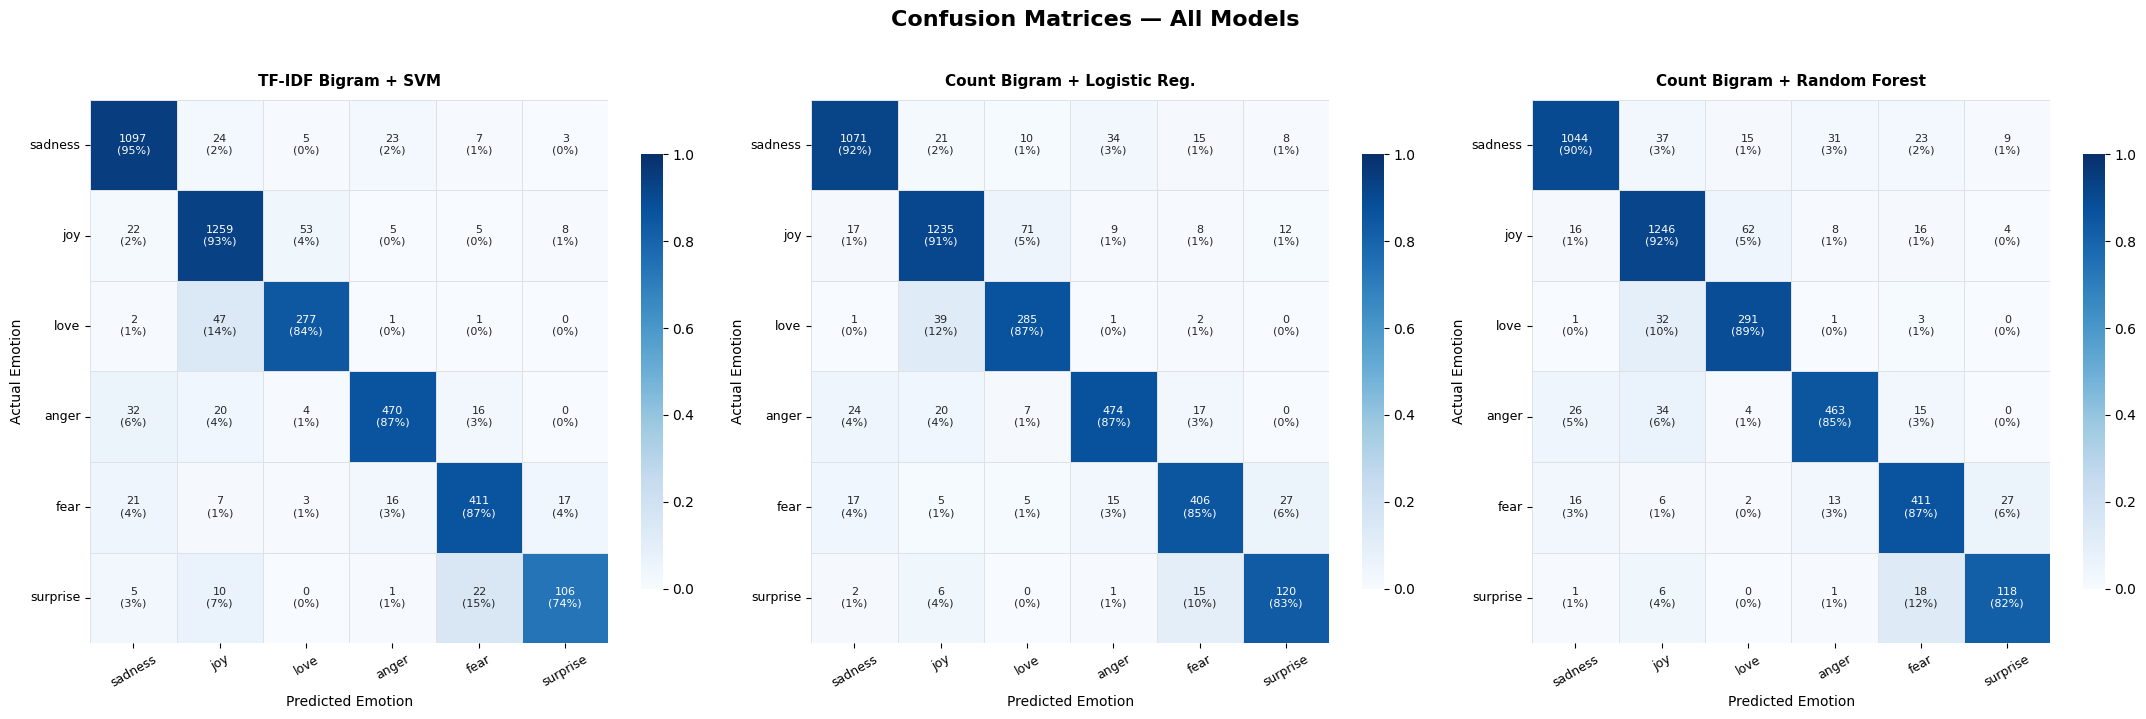

✅ Saved confusion_matrices.png


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

LABEL_NAMES = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

models_info = [
    ('TF-IDF Bigram + SVM',          y_pred_svm),
    ('Count Bigram + Logistic Reg.', y_pred_lr),
    ('Count Bigram + Random Forest', y_pred_rf),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Confusion Matrices \u2014 All Models',
             fontsize=16, fontweight='bold', y=1.02)

for ax, (name, y_pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_pred, labels=LABEL_NAMES)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # Annotation: raw count on top line, percentage on second line
    annot = np.array(
        [['{:d}\n({:.0%})'.format(cm[i, j], cm_norm[i, j])
          for j in range(len(LABEL_NAMES))]
         for i in range(len(LABEL_NAMES))]
    )

    sns.heatmap(
        cm_norm,
        annot=annot,
        fmt='',
        cmap='Blues',
        xticklabels=LABEL_NAMES,
        yticklabels=LABEL_NAMES,
        linewidths=0.5,
        linecolor='#dee2e6',
        vmin=0,
        vmax=1,
        ax=ax,
        annot_kws={'size': 8},
        cbar_kws={'shrink': 0.8},
    )
    ax.set_title(name, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Emotion', fontsize=10)
    ax.set_ylabel('Actual Emotion', fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2705 Saved confusion_matrices.png')


### 6b. DistilBERT Confusion Matrix
Loads the **fine-tuned DistilBERT** model saved by `train_transformer.py` and plots its confusion matrix on the same test set used by the classical models.
The purple colour scheme helps visually separate it from the classical models (blue).

Loading DistilBERT from ../models/distilbert_emotion ...


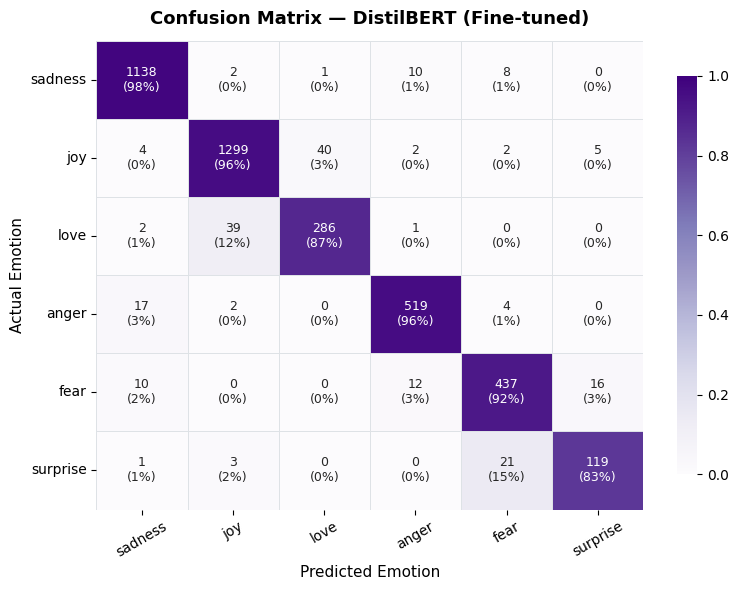

✅ Saved confusion_matrix_distilbert.png
DistilBERT  Accuracy=0.9495  F1=0.9494


In [11]:
# DistilBERT Confusion Matrix
# Loads the full fine-tuned model saved by train_transformer.py
# and runs inference on the same X_test used by classical models.
import os, pathlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

LABEL_NAMES    = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
MODEL_DIR      = pathlib.Path('..') / 'models' / 'distilbert_emotion'

if not MODEL_DIR.exists():
    print('\u26a0\ufe0f  DistilBERT model not found at', MODEL_DIR)
    print('   Run: python -m src.train_transformer   from the project root first.')
else:
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification

    print('Loading DistilBERT from', MODEL_DIR, '...')
    tokenizer_bert = AutoTokenizer.from_pretrained(str(MODEL_DIR))
    model_bert     = AutoModelForSequenceClassification.from_pretrained(str(MODEL_DIR))
    model_bert.eval()

    # id2label stored in config tells us the label order
    id2label = model_bert.config.id2label   # e.g. {0: 'sadness', 1: 'joy', ...}

    # Run inference in small batches to avoid OOM
    BATCH = 64
    texts  = X_test.tolist()
    preds  = []
    for start in range(0, len(texts), BATCH):
        batch = texts[start: start + BATCH]
        enc   = tokenizer_bert(batch, truncation=True, padding=True,
                               max_length=128, return_tensors='pt')
        with torch.no_grad():
            logits = model_bert(**enc).logits
        preds.extend(logits.argmax(dim=-1).tolist())

    y_pred_bert = [id2label[p] for p in preds]

    cm      = confusion_matrix(y_test, y_pred_bert, labels=LABEL_NAMES)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    annot = np.array(
        [['{:d}\n({:.0%})'.format(cm[i, j], cm_norm[i, j])
          for j in range(len(LABEL_NAMES))]
         for i in range(len(LABEL_NAMES))]
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm_norm, annot=annot, fmt='', cmap='Purples',
        xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
        linewidths=0.5, linecolor='#dee2e6',
        vmin=0, vmax=1, ax=ax,
        annot_kws={'size': 9},
        cbar_kws={'shrink': 0.85},
    )
    ax.set_title('Confusion Matrix \u2014 DistilBERT (Fine-tuned)',
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Emotion', fontsize=11)
    ax.set_ylabel('Actual Emotion', fontsize=11)
    ax.tick_params(axis='x', rotation=30, labelsize=10)
    ax.tick_params(axis='y', rotation=0, labelsize=10)
    plt.tight_layout()
    plt.savefig('confusion_matrix_distilbert.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\u2705 Saved confusion_matrix_distilbert.png')
    from sklearn.metrics import accuracy_score, precision_recall_fscore_support
    acc = accuracy_score(y_test, y_pred_bert)
    _, _, f1, _ = precision_recall_fscore_support(y_test, y_pred_bert,
                                                  average='weighted', zero_division=0)
    print(f'DistilBERT  Accuracy={acc:.4f}  F1={f1:.4f}')


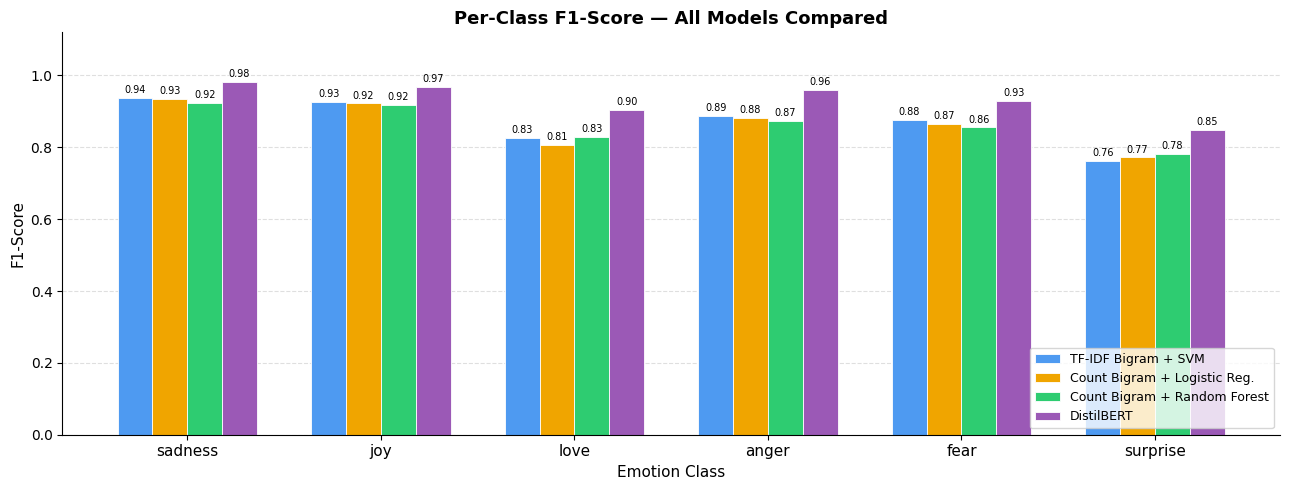

✅ Saved per_class_f1_all_models.png


,TF-IDF Bigram + SVM,Count Bigram + Logistic Reg.,Count Bigram + Random Forest,DistilBERT
sadness,0.938,0.935,0.923,0.981
joy,0.926,0.922,0.919,0.968
love,0.827,0.807,0.829,0.904
anger,0.888,0.881,0.874,0.960
fear,0.877,0.866,0.855,0.928
surprise,0.763,0.772,0.781,0.848


In [12]:
# Per-class F1 comparison — all models side by side
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathlib

LABEL_NAMES = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

# ── Classical models (live predictions) ──────────────────────────────────────
classical_models = [
    ('TF-IDF Bigram + SVM',          y_pred_svm),
    ('Count Bigram + Logistic Reg.', y_pred_lr),
    ('Count Bigram + Random Forest', y_pred_rf),
]

all_models = []   # list of (name, f1_per_class_array)
for name, y_pred in classical_models:
    report = classification_report(
        y_test, y_pred, labels=LABEL_NAMES, output_dict=True, zero_division=0)
    f1s = [report[label]['f1-score'] for label in LABEL_NAMES]
    all_models.append((name, np.array(f1s)))

# ── DistilBERT: load per-class F1 from model_results_details.json ─────────────
details_path = pathlib.Path('..') / 'models' / 'classical' / 'model_results_details.json'
if details_path.exists():
    import json as _json
    details = _json.loads(details_path.read_text(encoding='utf-8'))
    bert_detail = next((d for d in details if d.get('display_name') == 'DistilBERT'), None)
    if bert_detail and 'classification_report' in bert_detail:
        cr = bert_detail['classification_report']
        f1s = [cr.get(label, {}).get('f1-score', 0.0) for label in LABEL_NAMES]
        all_models.append(('DistilBERT', np.array(f1s)))
    else:
        print('\u26a0\ufe0f  DistilBERT per-class report not found in details JSON.')

# ── Grouped bar chart ─────────────────────────────────────────────────────────
n_models  = len(all_models)
n_labels  = len(LABEL_NAMES)
x         = np.arange(n_labels)
bar_width = 0.18
colors    = ['#4e9af1', '#f0a500', '#2ecc71', '#9b59b6']   # blue, gold, green, purple

fig, ax = plt.subplots(figsize=(13, 5))

for idx, (name, f1s) in enumerate(all_models):
    offsets = x + (idx - (n_models - 1) / 2) * bar_width
    bars = ax.bar(offsets, f1s, width=bar_width,
                  label=name, color=colors[idx % len(colors)],
                  edgecolor='white', linewidth=0.6)
    ax.bar_label(bars, fmt='%.2f', fontsize=7, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(LABEL_NAMES, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('F1-Score', fontsize=11)
ax.set_xlabel('Emotion Class', fontsize=11)
ax.set_title('Per-Class F1-Score \u2014 All Models Compared', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('per_class_f1_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2705 Saved per_class_f1_all_models.png')

# ── Summary table ─────────────────────────────────────────────────────────────
table = pd.DataFrame(
    {name: f1s for name, f1s in all_models},
    index=LABEL_NAMES
).round(3)

display(
    table.style
    .background_gradient(cmap='Blues', axis=None, vmin=0.6, vmax=1.0)
    .format('{:.3f}')
    .set_caption('Per-class F1-Score for all models (higher = better)')
)
